In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns

In [2]:
# Load the dataset
data_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(data_url)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
# Print summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [4]:
# Drop rows with missing values and select some features
df = df.dropna()
features = ['horsepower', 'weight', 'displacement', 'acceleration', 'cylinders']
target = 'mpg'

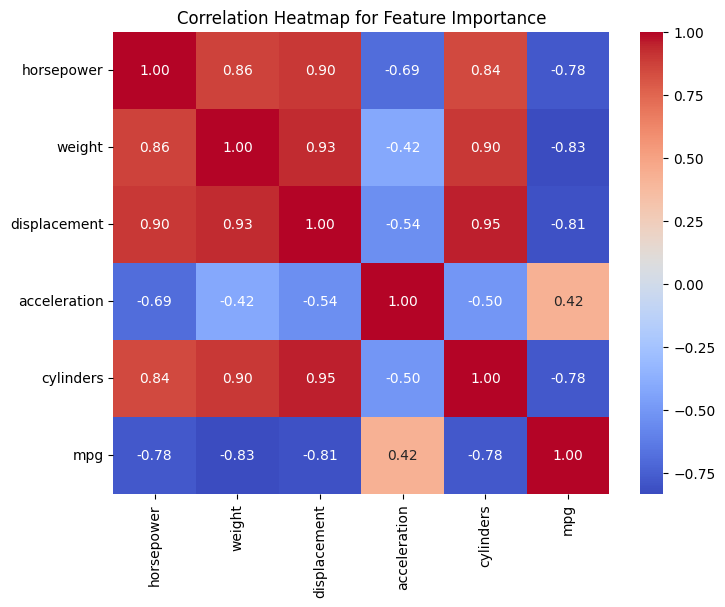

In [5]:
# Calculate correlation matrix
correlation_matrix = df[features + [target]].corr()

# Plot heatmap of feature importance
plt.figure(figsize = (8,6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap for Feature Importance')
plt.show()

In [6]:
# Select features from the correlation matrix and use mpg as the target variable
X = df[['horsepower', 'weight', 'displacement', 'cylinders']].values
Y = df['mpg'].values

In [7]:
# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state=42)

In [8]:
# Create a Linear Regression model
# Initialize an instance of a Linear Regression model from scikit-learn
model = LinearRegression()

# Train the model
# it holds the linear regression model
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# Make predictions on the test set
Y_pred = model.predict(X_test)

In [10]:
# Evaluate the model
mse = mean_squared_error(Y_test, Y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 17.89


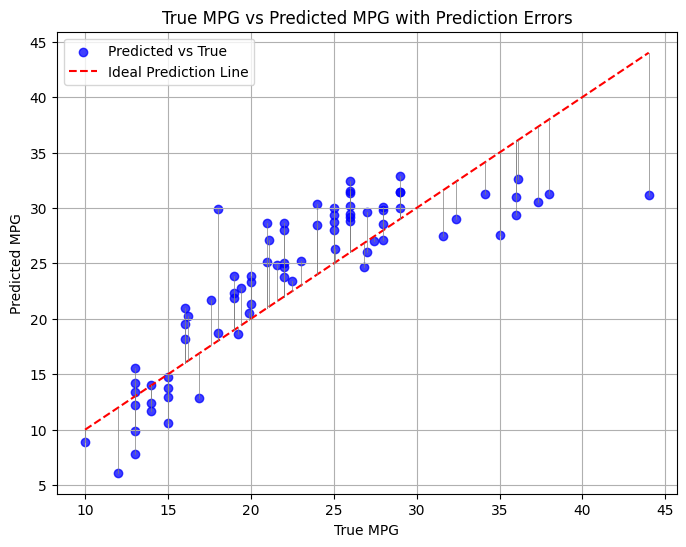

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB


In [11]:
# Plot the true vs predicted mpg
plt.figure(figsize=(8,6))
plt.scatter(Y_test, Y_pred, alpha=0.75, color='blue', label='Predicted vs True')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--', label='Ideal Prediction Line')

# Calculate and plot prediction errors
for (true_value, predicted_value) in zip(Y_test, Y_pred):
    plt.plot([true_value, true_value], [true_value, predicted_value], color='gray', linestyle='-', linewidth=0.5)

plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
plt.title("True MPG vs Predicted MPG with Prediction Errors")
plt.legend()
plt.grid(True)
plt.show()  # just show the plot

# Now inspect your DataFrame separately
df.info()  # or whatever DataFrame you want to check